In [1]:
# Labial 

import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[2]
sys.path.insert(0, str(REPO_ROOT / "code"))
from model_unified_ver import run_exp
from model_unified_ver import default_params as params
import utils as utl
from analysis_of_simulation_result import * 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import os 
import pickle
from make_network import * 
from fitting import * 
c2g = dict(zip(target_ids_valid_all,g_info_all))

In [2]:
params_opt_tarsal = pickle.load(open(REPO_ROOT/'figure4/figure4F-K.MN9_PER_fitting/fitting_result/tarsal/result_av1a1_170.pkl','rb'))

V_at,K_at,n_at,V_tp,K_tp,n_tp,k_act_T,r0_T,h_T = params_opt_tarsal.x


firing = [(0,0),*[(np.round(hill(c,V_at,K_at,n_at),1),np.round(hill(c,V_tp,K_tp,n_tp),1)) for c in [10,50,100,500]]]

popt_tarsal = [k_act_T,r0_T,h_T]

In [3]:
def get_val_each_trial(spikes,popt,mode='PER'):
    concents = [100]
    val_per_concent = {}
    for j,g in enumerate(concents):
        trials = np.zeros(100)
        for i,t_df in spikes[j].groupby(by='trial'):
            trials[t_df.trial.values[0]] = len(t_df)/2
        if mode == 'PER':
            y = sigmoid(trials,*popt)
        elif mode == 'MN9':
            y = trials
        val_per_concent[g] = y
    return val_per_concent


def get_error(spikes,popt,mode='PER'):
    concents = [0,10,50,100,500]
    std_control = {}
    for j,g in enumerate(concents):
        trials = np.zeros(100)
        for i,t_df in spikes[j].groupby(by='trial'):
            trials[t_df.trial.values[0]] = len(t_df)/2
        if mode == 'PER':
            y = sigmoid(trials,*popt)
        elif mode == 'MN9':
            y = trials
        std_control[g] = np.std(y)/np.sqrt(len(y))
    return std_control

In [3]:
from scipy.stats import hmean
mn9 = [720575940660219265,720575940618238523]


ff1,ff2 = firing[-2]
# sugar only condition 
path = f'/volume_4/research/seongbong/flywire/geosmin_project_version_update/figure_supplementary/figure2/each_leg_simulation/result_mid_hindleg'
total_group = [f'{ff1}Hz_{ff2}Hz_0Hz.parquet']
total_paths = [f'{path}/{x}' for x in total_group]
df_rate_s,spikes_control,_ = read_result_with_multi_thread(total_paths,mn9,"MN9")
df_rate_s = df_rate_s[0]
# spikes_suc_per_concent[c] = spikes_control


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 3134.76it/s]


In [29]:
# from scipy.stats import hmean
# mn9 = [720575940660219265,720575940618238523]

# spikes_per_condition = {}
# PER_suc_per_cond = {}
# MN9_suc_per_cond = {}
# for cond in ['foreleg','mid_hindleg','only_TPN1']:
#     ff1,ff2 = firing[-2]
#     # sugar only condition 
#     path = f'/volume_4/research/seongbong/flywire/geosmin_project_version_update/figure_supplementary/figure2/each_leg_simulation/result_{cond}'
#     if cond == 'only_TPN1':
#         ff1 = 0
#     total_group = [f'{ff1}Hz_{ff2}Hz_0Hz.parquet']
#     total_paths = [f'{path}/{x}' for x in total_group]
#     df_rate_s,spikes_control,_ = read_result_with_multi_thread(total_paths,mn9,"MN9")
#     df_rate_s = df_rate_s[0]
#     spikes_per_condition[cond] = spikes_control

#     sugar = sigmoid(df_rate_s[f'{ff1}Hz_{ff2}Hz_0Hz'].values,*[k_act_T,r0_T,h_T])
#     MN9_suc_per_cond[cond] = df_rate_s.loc['MN9'].values[0]
#     PER_suc_per_cond[cond] = sugar 
# concents = [10,50,100,500]
# std_control = {}
# for g in MN9_suc_per_cond.keys():
#     trials = np.zeros(100)
#     for i,t_df in spikes_per_condition[g][0].groupby(by='trial'):
#         trials[t_df.trial.values[0]] = len(t_df)
#     y = trials
#     std_control[g] = np.std(y)/np.sqrt(len(y))
# pivot_df = pd.concat([mean_mat,std_mat],axis=1)
# pivot_df.columns =['PER','SEM']
# pivot_df.to_parquet('result_data/Each_leg_simulation.parquet')
# pickle.dump(spikes_per_condition,open('result_data/Each_leg_simulation_spike_data.pkl','wb'))
spikes_per_condition = pickle.load(open('result_data/Each_leg_simulation_spike_data.pkl','rb'))
pivot_df = pd.read_parquet('result_data/Each_leg_simulation.parquet')

In [7]:
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = fontsize = 7 

colors = cmap = ['#13739E','#952B7E']


Text(0, 0.5, 'Firing rate (Hz)')

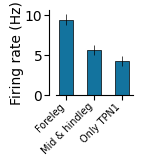

In [30]:
colors = cmap = ['#13739E','#952B7E']
df = pd.DataFrame.from_dict(MN9_suc_per_cond,orient='index')
df = df.sort_values(by=0,ascending=False)

bar_spacing = .15
num_bars = len(pivot_df)
xloc = np.arange(0, num_bars * bar_spacing, bar_spacing)  
bar_width = .075


fig,ax = plt.subplots(1,1,figsize=(1,1.1))
b1 = ax.bar(xloc , pivot_df['PER'], yerr=pivot_df['SEM'], width=bar_width, label='sugar', color=cmap[0],edgecolor='black',linewidth=.5, error_kw=dict(capsize=0,elinewidth=.5))



x = np.arange(0, num_bars * bar_spacing, bar_spacing)
xlabel = ['Foreleg','Mid & hindleg','Only TPN1']
ax.set_xticks(xloc,xlabel,fontsize=7,rotation=45,ha='right')
ax.spines[['top','right']].set_visible(False)
ax.spines['left'].set_position(('outward', 5))
ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5
ax.tick_params(pad=1)
ax.set_ylabel('Firing rate (Hz)')
# df.loc['control',0] = PER_suc_per_concent[concentration]
# df = df.loc[np.concatenate([[df.index[-1]],df.index.values[:-1]])]
# plt.savefig('Each_leg_simulation.svg')

In [10]:
import pandas as pd
from scipy.stats import shapiro,kruskal
import scikit_posthocs as sp


def sigmoid(x,k, x0,h):
    return h / (1 + np.exp(-k * (x - x0)))

a = get_val_each_trial(spikes_per_condition['foreleg'], popt_tarsal, mode='MN9')
b = get_val_each_trial(spikes_per_condition['mid_hindleg'], popt_tarsal, mode='MN9')
c = get_val_each_trial(spikes_per_condition['only_TPN1'], popt_tarsal, mode='MN9')


datasets = {
    "a": a,
    "b": b,
    "c": c,
}

for name, data in datasets.items():
    print(f"\n{name}")
    for conc in sorted(data.keys()):
        result = shapiro(data[conc])
        print(
            f"{conc:>3} mM: "
            f"W = {result.statistic:.3e}, "
            f"p = {result.pvalue:.3e}"
        )
        
        
# -----------------------------
# Kruskal + Dunn
# -----------------------------
print("\n\n### Kruskal-Wallis + Dunn's post hoc ###")

for conc in sorted(a.keys()):

    print(f"\n===== {conc} mM =====")

    # Kruskal-Wallis
    H, p = kruskal(a[conc], b[conc], c[conc])

    print(f"Kruskal-Wallis: H = {H:.3e}, p = {p:.3e}")

    # Post hoc only if significant
    if p < 0.05:

        df = pd.DataFrame({
            "value": np.concatenate([
                a[conc],
                b[conc],
                c[conc]
            ]),
            "group": (
                ["Foreleg"] * len(a[conc]) +
                ["Mid/Hindleg"] * len(b[conc]) +
                ["Only TPN1"] * len(c[conc])
            )
        })

        dunn = sp.posthoc_dunn(
            df,
            val_col="value",
            group_col="group",
            p_adjust="holm"
        )

        print("\nDunn's post hoc (Holm corrected)")
        print(dunn)


a
100 mM: W = 9.860e-01, p = 3.743e-01

b
100 mM: W = 9.824e-01, p = 2.032e-01

c
100 mM: W = 9.519e-01, p = 1.101e-03


### Kruskal-Wallis + Dunn's post hoc ###

===== 100 mM =====
Kruskal-Wallis: H = 9.646e+01, p = 1.132e-21

Dunn's post hoc (Holm corrected)
                  Foreleg   Mid/Hindleg     Only TPN1
Foreleg      1.000000e+00  2.560663e-11  4.015120e-21
Mid/Hindleg  2.560663e-11  1.000000e+00  5.504927e-03
Only TPN1    4.015120e-21  5.504927e-03  1.000000e+00


In [31]:
import pandas as pd
from scipy.stats import shapiro,kruskal
import scikit_posthocs as sp


def sigmoid(x,k, x0,h):
    return h / (1 + np.exp(-k * (x - x0)))

a = get_val_each_trial(spikes_per_condition['foreleg'], popt_tarsal, mode='MN9')
b = get_val_each_trial(spikes_per_condition['mid_hindleg'], popt_tarsal, mode='MN9')
c = get_val_each_trial(spikes_per_condition['only_TPN1'], popt_tarsal, mode='MN9')


datasets = {
    "a": a,
    "b": b,
    "c": c,
}

for name, data in datasets.items():
    print(f"\n{name}")
    for conc in sorted(data.keys()):
        result = shapiro(data[conc])
        print(
            f"{conc:>3} mM: "
            f"W = {result.statistic:.3e}, "
            f"p = {result.pvalue:.3e}"
        )
        
        
# -----------------------------
# Kruskal + Dunn
# -----------------------------
print("\n\n### Kruskal-Wallis + Dunn's post hoc ###")

for conc in sorted(a.keys()):

    print(f"\n===== {conc} mM =====")

    # Kruskal-Wallis
    H, p = kruskal(a[conc], b[conc], c[conc])

    print(f"Kruskal-Wallis: H = {H:.3e}, p = {p:.3e}")

    # Post hoc only if significant
    if p < 0.05:

        df = pd.DataFrame({
            "value": np.concatenate([
                a[conc],
                b[conc],
                c[conc]
            ]),
            "group": (
                ["Foreleg"] * len(a[conc]) +
                ["Mid/Hindleg"] * len(b[conc]) +
                ["Only TPN1"] * len(c[conc])
            )
        })

        dunn = sp.posthoc_dunn(
            df,
            val_col="value",
            group_col="group",
            p_adjust="holm"
        )

        print("\nDunn's post hoc (Holm corrected)")
        print(dunn)

NameError: name 'get_val_each_trial' is not defined